# 02. Bottleneck_analysis

In [68]:
# 단일 수리 vs 복합 수리
group_summary = (repair_merged_df.groupby("repair_group", dropna = False)
                 .agg(case_cnt = ("caseID", "count")
                      , avg_estimated_time = ("EstimatedRepairTime", "mean")
                      , avg_actual_time = ("actual_repair_time_minutes", "mean") # 실제 수리 시간
                      , avg_diff_minutes = ("repair_time_diff", "mean") # 실제 수리 시간 - 예상 수리 시간
                      , median_diff_minutes = ("repair_time_diff", "median")
        )
    .reset_index()
    )
group_summary

,repair_group,case_cnt,avg_estimated_time,avg_actual_time,avg_diff_minutes,median_diff_minutes
0,MultipleRepair,127,176.377953,863.244094,686.866142,216.0
1,SingleRepair,800,197.200000,200.155000,2.955000,0.0
2,unknown,73,NaN,NaN,NaN,NaN


In [69]:
seq_summary = (repair_merged_df.groupby("repair_sequence", dropna = False)
               .agg(case_cnt = ("caseID", "count")
                    , avg_estimated_time = ("EstimatedRepairTime", "mean")
                    , avg_actual_time = ("actual_repair_time_minutes", "mean")
                    , max_minute=('repair_time_diff', 'max')
                    , avg_diff_minutes = ("repair_time_diff", "mean")
                   )
               .reset_index()
               .sort_values(["avg_diff_minutes", "case_cnt"], ascending = [False, False])
              )

seq_summary['avg_diff_hours'] = seq_summary['avg_diff_minutes'] / 60
seq_summary['avg_diff_days'] = seq_summary['avg_diff_minutes'] / (24 * 60)
seq_summary['max_days'] = seq_summary['max_minute'] / (24 * 60)
seq_summary

,repair_sequence,case_cnt,avg_estimated_time,avg_actual_time,max_minute,avg_diff_minutes,avg_diff_hours,avg_diff_days,max_days
8,InternRepair > InternRepair,35,232.000000,2196.714286,14736.0,1964.714286,32.745238,1.364385,10.233333
10,InternRepair > InternRepair > InternRepair,1,240.000000,1575.000000,1335.0,1335.000000,22.250000,0.927083,0.927083
9,InternRepair > InternRepair > ExternRepair,1,240.000000,576.000000,336.0,336.000000,5.600000,0.233333,0.233333
5,ImmediateRepair > InternRepair > InternRepair,1,120.000000,426.000000,306.0,306.000000,5.100000,0.212500,0.212500
4,ImmediateRepair > InternRepair > ExternRepair,5,120.000000,396.200000,315.0,276.200000,4.603333,0.191806,0.218750
7,InternRepair > ExternRepair,29,227.586207,472.965517,330.0,245.379310,4.089655,0.170402,0.229167
3,ImmediateRepair > InternRepair,17,120.000000,304.647059,480.0,184.647059,3.077451,0.128227,0.333333
2,ImmediateRepair > ExternRepair,38,116.842105,244.578947,192.0,127.736842,2.128947,0.088706,0.133333
0,ExternRepair,59,402.711864,451.525424,240.0,48.813559,0.813559,0.033898,0.166667
1,ImmediateRepair,322,117.018634,116.478261,12.0,-0.540373,-0.009006,-0.000375,0.008333


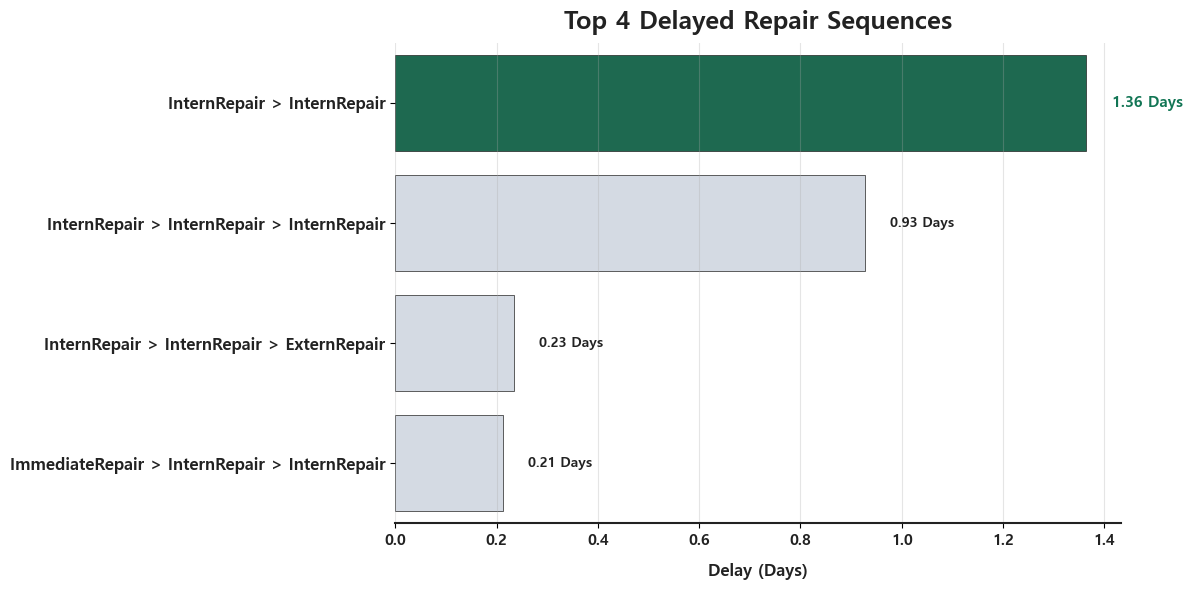

In [71]:
# 상위 4개 시퀀스 구성
df_top4 = seq_summary.head(4)

fig, ax = plt.subplots(figsize = (12, 6))

highlight_color = "#117554" # 초록
base_color = "#D1D9E6" # 회색
text_dark = "#222222" # 검정
grid_color = "#AAAAAA" # 진한 회색

colors = [highlight_color if name == "InternRepair > InternRepair" else base_color
          for name in df_top4["repair_sequence"]]

barplot = sns.barplot(x = "avg_diff_days"
                      , y = "repair_sequence"
                      , data = df_top4
                      , palette = colors
                      , edgecolor = text_dark
                      , linewidth = 0.5
                     )

for i, bar in enumerate(barplot.patches):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if df_top4.iloc[i]["repair_sequence"] == "InternRepair > InternRepair":
        plt.text(width + 0.05, y, f"{width:.2f} Days",
                 va = "center", fontsize = 11, color = highlight_color, fontweight = "black")
    else:
        plt.text(width + 0.05, y, f"{width:.2f} Days",
                 va = "center", fontsize = 10, color = text_dark, fontweight = "bold")

plt.title("Top 4 Delayed Repair Sequences", fontsize = 18, fontweight = "black", pad = 10, color = text_dark)
plt.xlabel("Delay (Days)", fontsize = 12, labelpad = 10, fontweight = "bold", color = text_dark)
plt.ylabel("", fontsize = 12)

plt.xticks(fontsize = 11, color = text_dark, fontweight = "bold")
plt.yticks(fontsize = 12, color = text_dark, fontweight = "bold")

sns.despine(left = True, bottom = True)

ax = plt.gca()
ax.xaxis.grid(True, linestyle = '-', alpha = 0.3, color = grid_color) # 그리드 선명하게
ax.spines['bottom'].set_color(text_dark) # 하단 축 선 진하게
ax.spines['bottom'].set_linewidth(1.5)
sns.despine(left = True, bottom = False)

plt.tight_layout()

plt.savefig("Top 4 Delayed Repair Sequences", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [72]:
# 전체 프로세스 단계별 평균 bottleneck
steps = {
    "caseID" : (repair_merged_df["caseID"])
    , "FirstContact > MakeTicket" : (repair_merged_df["MakeTicket_start"] - repair_merged_df["FirstContact_end"]).dt.total_seconds() / 60
    , "MakeTicket > ArrangeSurvey" : (repair_merged_df["ArrangeSurvey_start"] - repair_merged_df["MakeTicket_end"]).dt.total_seconds() / 60
    , "ArrangeSurvey > InformClientSurvey" : (repair_merged_df["InformClientSurvey_end"] - repair_merged_df["ArrangeSurvey_end"]).dt.total_seconds() / 60
    , "InformClientSurvey > Survey" : (repair_merged_df["Survey_start"] - repair_merged_df["InformClientSurvey_end"]).dt.total_seconds() / 60
    , "Survey > InternRepair" : (repair_merged_df["InternRepair_start"] - repair_merged_df["Survey_end"]).dt.total_seconds() / 60
    , "Survey > ImmediateRepair" : (repair_merged_df["ImmediateRepair_start"] - repair_merged_df["Survey_end"]).dt.total_seconds() / 60
    , "Survey > ExternRepair" : (repair_merged_df["ExternRepair_start"] - repair_merged_df["Survey_end"]).dt.total_seconds() / 60
    , "InternRepair > RepairReady" : (repair_merged_df["RepairReady_end"] - repair_merged_df["InternRepair_end"]).dt.total_seconds() / 60
    , "ImmediateRepair > RepairReady" : (repair_merged_df["RepairReady_end"] - repair_merged_df["ImmediateRepair_end"]).dt.total_seconds() / 60
    , "ExternRepair > RepairReady" : (repair_merged_df["RepairReady_end"] - repair_merged_df["ExternRepair_start"]).dt.total_seconds() / 60
    , "RepairReady > SendTicketToFinAdmin" : (repair_merged_df["SendTicketToFinAdmin_end"] - repair_merged_df["RepairReady_end"]).dt.total_seconds() / 60
    , "SendTicketToFinAdmin > ReadyForInformClient" : (repair_merged_df["ReadyForInformClient_end"] - repair_merged_df["SendTicketToFinAdmin_end"]).dt.total_seconds() / 60
    , "ReadyForInformClient > TicketReady" : (repair_merged_df["TicketReady_end"] - repair_merged_df["ReadyForInformClient_end"]).dt.total_seconds() / 60
}
step_df = pd.DataFrame(steps)
step_df

,caseID,FirstContact > MakeTicket,MakeTicket > ArrangeSurvey,ArrangeSurvey > InformClientSurvey,InformClientSurvey > Survey,Survey > InternRepair,Survey > ImmediateRepair,Survey > ExternRepair,InternRepair > RepairReady,ImmediateRepair > RepairReady,ExternRepair > RepairReady,RepairReady > SendTicketToFinAdmin,SendTicketToFinAdmin > ReadyForInformClient,ReadyForInformClient > TicketReady
0,1,0.0,0.0,0.0,13757.0,7600.0,NaN,NaN,0.0,NaN,NaN,351.0,101.0,0.0
1,2,0.0,0.0,0.0,5694.0,NaN,0.0,120.0,NaN,120.0,120.0,377.0,-237.0,237.0
2,3,0.0,0.0,0.0,4637.0,783.0,NaN,NaN,0.0,NaN,NaN,416.0,38.0,0.0
3,4,0.0,0.0,0.0,1951.0,NaN,0.0,NaN,NaN,0.0,NaN,233.0,-159.0,159.0
4,5,0.0,0.0,0.0,2983.0,NaN,0.0,NaN,NaN,0.0,NaN,295.0,-291.0,291.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,0.0,0.0,0.0,393.0,451.0,NaN,NaN,0.0,NaN,NaN,135.0,151.0,0.0
996,997,0.0,0.0,0.0,8025.0,3152.0,NaN,NaN,0.0,NaN,NaN,280.0,195.0,0.0
997,998,0.0,0.0,0.0,12618.0,4939.0,NaN,NaN,0.0,NaN,NaN,201.0,-131.0,131.0
998,999,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,432.0,242.0,-194.0,194.0


In [73]:
step_df.describe()

,FirstContact > MakeTicket,MakeTicket > ArrangeSurvey,ArrangeSurvey > InformClientSurvey,InformClientSurvey > Survey,Survey > InternRepair,Survey > ImmediateRepair,Survey > ExternRepair,InternRepair > RepairReady,ImmediateRepair > RepairReady,ExternRepair > RepairReady,RepairReady > SendTicketToFinAdmin,SendTicketToFinAdmin > ReadyForInformClient,ReadyForInformClient > TicketReady
count,927.0,927.0,927.0,927.000000,508.000000,383.0,132.000000,508.000000,383.000000,132.000000,927.000000,927.000000,927.000000
mean,0.0,0.0,0.0,4605.609493,1759.612205,0.0,278.962121,15.681102,25.274151,298.757576,245.382956,0.167206,84.754045
std,0.0,0.0,0.0,4704.818414,2724.293541,0.0,673.901520,59.282101,65.129637,158.870158,138.180607,204.491169,114.392281
min,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,54.000000,1.000000,-470.000000,0.000000
25%,0.0,0.0,0.0,405.000000,31.250000,0.0,0.000000,0.000000,0.000000,153.000000,130.000000,-161.000000,0.000000
50%,0.0,0.0,0.0,2926.000000,489.500000,0.0,108.000000,0.000000,0.000000,264.000000,247.000000,-6.000000,6.000000
75%,0.0,0.0,0.0,8004.000000,2439.750000,0.0,188.250000,0.000000,0.000000,405.000000,365.000000,149.500000,161.000000
max,0.0,0.0,0.0,19660.000000,14851.000000,0.0,4531.000000,336.000000,492.000000,720.000000,480.000000,470.000000,470.000000


In [74]:
sns.set_theme(style = "white") # 이 코드가 상단에 있어야 한글 인식이 

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["font.family"] = "Malgun Gothic"

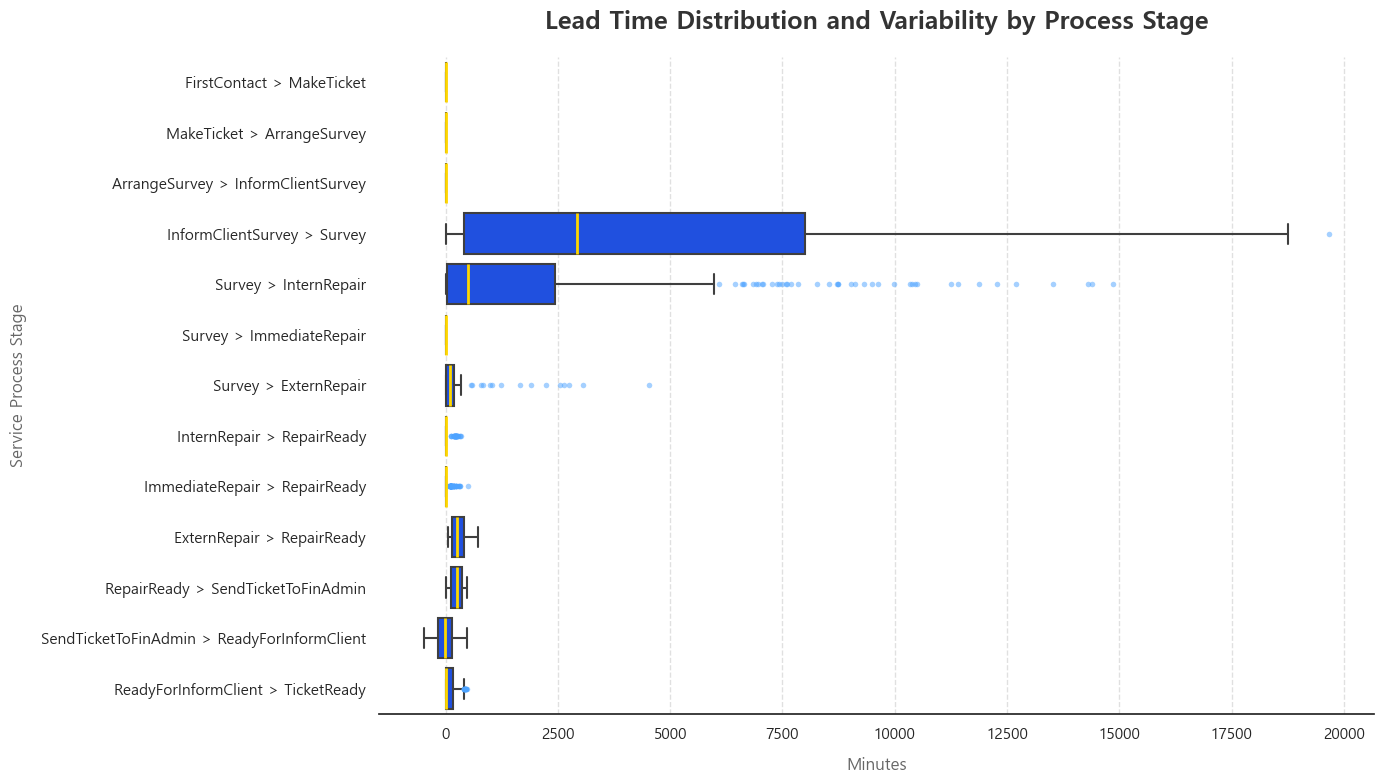

In [75]:
plt.figure(figsize = (14, 8))

ax = sns.boxplot(data = step_df
                 , orient = "h"
                 , color = "#0040FF"
                 , linewidth = 1.5
                 , fliersize = 4
                 , flierprops = {"marker": "o", "markerfacecolor": "#4DA3FF", "markeredgecolor": "none", "alpha": 0.5}
                 , medianprops = {"color" : "#FFD700", "linewidth": 2} # 중앙값 골드 컬러로 강조하여 포인트를 줌
                )

plt.title("Lead Time Distribution and Variability by Process Stage", fontsize = 18, pad = 20, weight = "bold", color='#333333')
plt.xlabel("Minutes", fontsize = 12, labelpad = 10, color = "#666666")
plt.ylabel("Service Process Stage", fontsize = 12, labelpad = 10, color = "#666666")

ax.xaxis.grid(True, linestyle = '--', alpha = 0.6)
ax.yaxis.grid(False)

sns.despine(left = True, bottom = False)

plt.tight_layout()
plt.show()

In [76]:
stage_cols = [
    'InformClientSurvey > Survey', 
    'Survey > InternRepair', 
    'Survey > ExternRepair'
]
# wide-form을 long-form으로 변환하고 일(Day) 단위 환산
df_stage_long = step_df[stage_cols].melt(var_name = 'target', value_name = 'diff_minutes')
df_stage_long['diff_days'] = df_stage_long['diff_minutes'] / (24 * 60)
df_stage_long['category'] = 'Stage'
df_stage_long.head()

,target,diff_minutes,diff_days,category
0,InformClientSurvey > Survey,13757.0,9.553472,Stage
1,InformClientSurvey > Survey,5694.0,3.954167,Stage
2,InformClientSurvey > Survey,4637.0,3.220139,Stage
3,InformClientSurvey > Survey,1951.0,1.354861,Stage
4,InformClientSurvey > Survey,2983.0,2.071528,Stage


In [77]:
repair_seqs = [
    'InternRepair > InternRepair',
    'InternRepair > InternRepair > InternRepair',
    'InternRepair > InternRepair > ExternRepair',
    'InternRepair > ExternRepair'
]
df_seq_long = repair_merged_df[repair_merged_df['repair_sequence'].isin(repair_seqs)].copy()
df_seq_long = df_seq_long[['repair_sequence', 'actual_repair_time_minutes']].rename(columns={'repair_sequence': 'target', 'actual_repair_time_minutes' : 'diff_minutes'})
df_seq_long['diff_days'] = df_seq_long['diff_minutes'] / (24 * 60)
df_seq_long['category'] = 'Sequence'
df_seq_long.head()

,target,diff_minutes,diff_days,category
11,InternRepair > InternRepair,1041.0,0.722917,Sequence
17,InternRepair > ExternRepair,456.0,0.316667,Sequence
28,InternRepair > ExternRepair,552.0,0.383333,Sequence
38,InternRepair > InternRepair,1162.0,0.806944,Sequence
50,InternRepair > ExternRepair,550.0,0.381944,Sequence


In [78]:
repair_top = (
    df_seq_long
    .groupby("target", as_index=False)
    .agg(
        avg_minutes=("diff_minutes", "mean"),
        avg_days=("diff_days", "mean")
    )
)

repair_top["category"] = "Sequence"
repair_top

,target,avg_minutes,avg_days,category
0,InternRepair > ExternRepair,472.965517,0.328448,Sequence
1,InternRepair > InternRepair,2196.714286,1.525496,Sequence
2,InternRepair > InternRepair > ExternRepair,576.000000,0.400000,Sequence
3,InternRepair > InternRepair > InternRepair,1575.000000,1.093750,Sequence


In [79]:
stage_top = (
    df_stage_long
    .groupby("target", as_index=False)
    .agg(
        avg_minutes=("diff_minutes", "mean"),
        avg_days=("diff_days", "mean")
    )
    .sort_values("avg_minutes", ascending=False)
)

stage_top["category"] = "Stage"
stage_top

,target,avg_minutes,avg_days,category
0,InformClientSurvey > Survey,4605.609493,3.198340,Stage
2,Survey > InternRepair,1759.612205,1.221953,Stage
1,Survey > ExternRepair,278.962121,0.193724,Stage


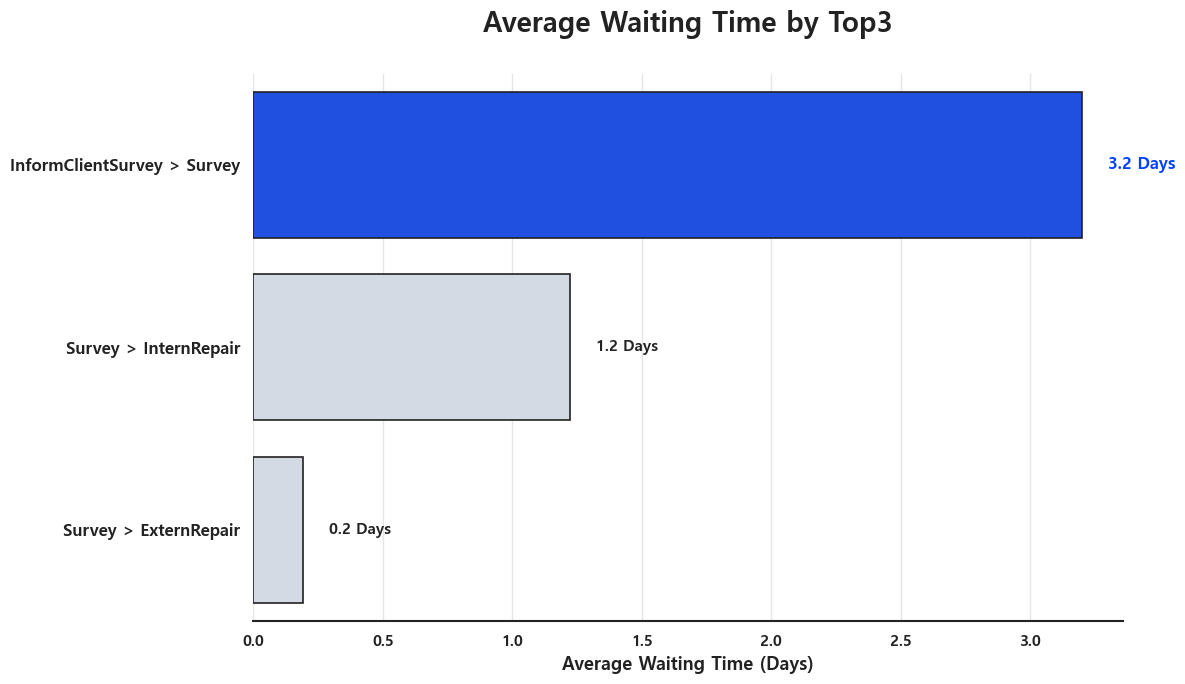

In [80]:
plt.figure(figsize = (12, 7))

highlight_color = "#0040FF"  # 강조 파랑
base_color = "#D1D9E6"
text_dark = "#222222"
grid_color = "#AAAAAA"

top_task_name = "InformClientSurvey > Survey"
colors = [highlight_color if task == top_task_name else base_color for task in stage_top["target"]]

barplot = sns.barplot(x = "avg_days"
                      , y = "target"
                      , data = stage_top
                      , palette = colors
                      , edgecolor = text_dark
                      , linewidth = 1.2
                     )

for i, bar in enumerate(barplot.patches):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if stage_top.iloc[i]["target"] == top_task_name:
        plt.text(width + 0.1, y, f"{width:.1f} Days"
                 , va = "center", ha = "left", fontsize = 12, color = highlight_color, fontweight = 'black')
    else:
        plt.text(width + 0.1, y, f"{width:.1f} Days"
                 , va = "center", ha = "left", fontsize = 11, color = text_dark, fontweight = 'bold')

plt.title("Average Waiting Time by Top3", fontsize = 20, fontweight = "black", pad = 30, color = text_dark)
plt.xlabel("Average Waiting Time (Days)", fontsize = 13, fontweight = "bold", color = text_dark)
plt.ylabel("", fontsize = 12)

plt.xticks(fontsize = 11, color = text_dark, fontweight = "bold")
plt.yticks(fontsize = 12, color = text_dark, fontweight = "bold")

# 그리드 설정
ax = plt.gca()
ax.xaxis.grid(True, linestyle = '-', alpha = 0.3, color = grid_color) # 그리드 선명하게
ax.spines['bottom'].set_color(text_dark) # 하단 축 선 진하게
ax.spines['bottom'].set_linewidth(1.5)
sns.despine(left = True, bottom = False)

plt.tight_layout()

In [81]:
df_total = (
    pd.concat([stage_top, repair_top], ignore_index=True)
      .sort_values("avg_minutes", ascending=False)
)

df_total

,target,avg_minutes,avg_days,category
0,InformClientSurvey > Survey,4605.609493,3.198340,Stage
4,InternRepair > InternRepair,2196.714286,1.525496,Sequence
1,Survey > InternRepair,1759.612205,1.221953,Stage
6,InternRepair > InternRepair > InternRepair,1575.000000,1.093750,Sequence
5,InternRepair > InternRepair > ExternRepair,576.000000,0.400000,Sequence
3,InternRepair > ExternRepair,472.965517,0.328448,Sequence
2,Survey > ExternRepair,278.962121,0.193724,Stage


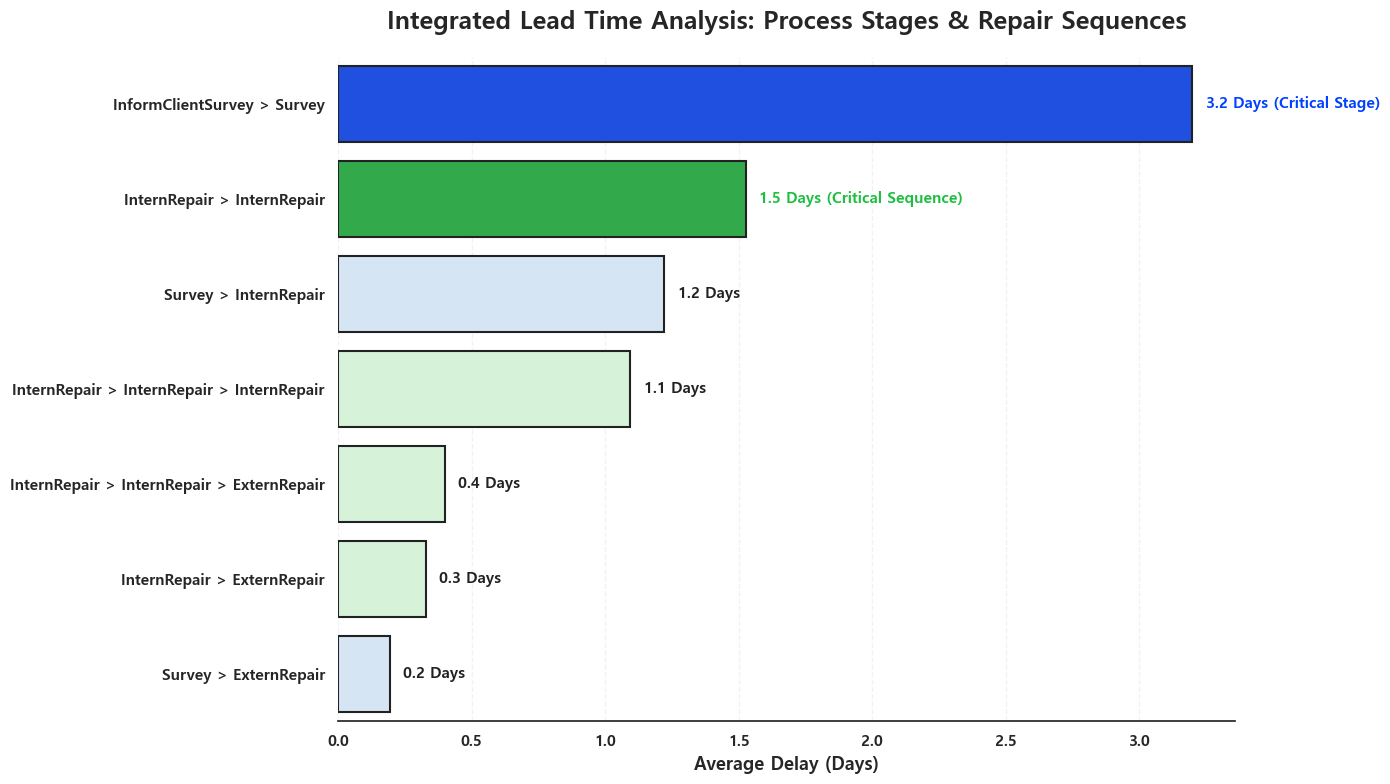

In [82]:
# ==========================================
# Palette
# ==========================================
pal = {
    'Stage_Crit': '#0040FF',
    'Stage_Base': '#D1E5F8',
    'Seq_Crit': '#1EBE41',
    'Seq_Base': '#D1F8D5'
}

text_dark = "#222222"

# ==========================================
# Plot Data
# ==========================================
df_bar = df_total.copy()
df_bar = df_bar.sort_values("avg_days", ascending=False).reset_index(drop=True)

# 색상 지정
colors = []

for _, row in df_bar.iterrows():

    if row["category"] == "Stage":
        if row["target"] == "InformClientSurvey > Survey":
            colors.append(pal["Stage_Crit"])
        else:
            colors.append(pal["Stage_Base"])

    else:
        if row["target"] == "InternRepair > InternRepair":
            colors.append(pal["Seq_Crit"])
        else:
            colors.append(pal["Seq_Base"])


# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=df_bar,
    x="avg_days",
    y="target",
    palette=colors,
    edgecolor=text_dark,
    linewidth=1.5
)

# ==========================================
# Annotation
# ==========================================
for bar, (_, row) in zip(ax.patches, df_bar.iterrows()):

    width = bar.get_width()
    y = bar.get_y() + bar.get_height()/2

    # 강조 대상
    is_critical = (
        row["target"] == "InformClientSurvey > Survey"
        or
        row["target"] == "InternRepair > InternRepair"
    )

    if row["category"] == "Stage":
        txt_color = pal["Stage_Crit"] if is_critical else text_dark
    else:
        txt_color = pal["Seq_Crit"] if is_critical else text_dark

    label = (
        f"{width:.1f} Days (Critical {row['category']})"
        if is_critical
        else f"{width:.1f} Days"
    )

    plt.text(
        width + 0.05,
        y,
        label,
        va="center",
        ha="left",
        fontsize=11,
        color=txt_color,
        fontweight="bold"
    )


# ==========================================
# Style
# ==========================================
plt.title(
    "Integrated Lead Time Analysis: Process Stages & Repair Sequences",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Average Delay (Days)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("")

plt.xticks(fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")

ax.xaxis.grid(True, linestyle="--", alpha=0.25)

sns.despine(left=True)

plt.tight_layout()
plt.show()

In [83]:
df_plot = pd.concat([df_stage_long, df_seq_long], axis = 0).dropna()
df_plot

,target,diff_minutes,diff_days,category
0,InformClientSurvey > Survey,13757.0,9.553472,Stage
1,InformClientSurvey > Survey,5694.0,3.954167,Stage
2,InformClientSurvey > Survey,4637.0,3.220139,Stage
3,InformClientSurvey > Survey,1951.0,1.354861,Stage
4,InformClientSurvey > Survey,2983.0,2.071528,Stage
...,...,...,...,...
922,InternRepair > ExternRepair,552.0,0.383333,Sequence
949,InternRepair > InternRepair,1892.0,1.313889,Sequence
953,InternRepair > InternRepair,12742.0,8.848611,Sequence
954,InternRepair > InternRepair,6813.0,4.731250,Sequence


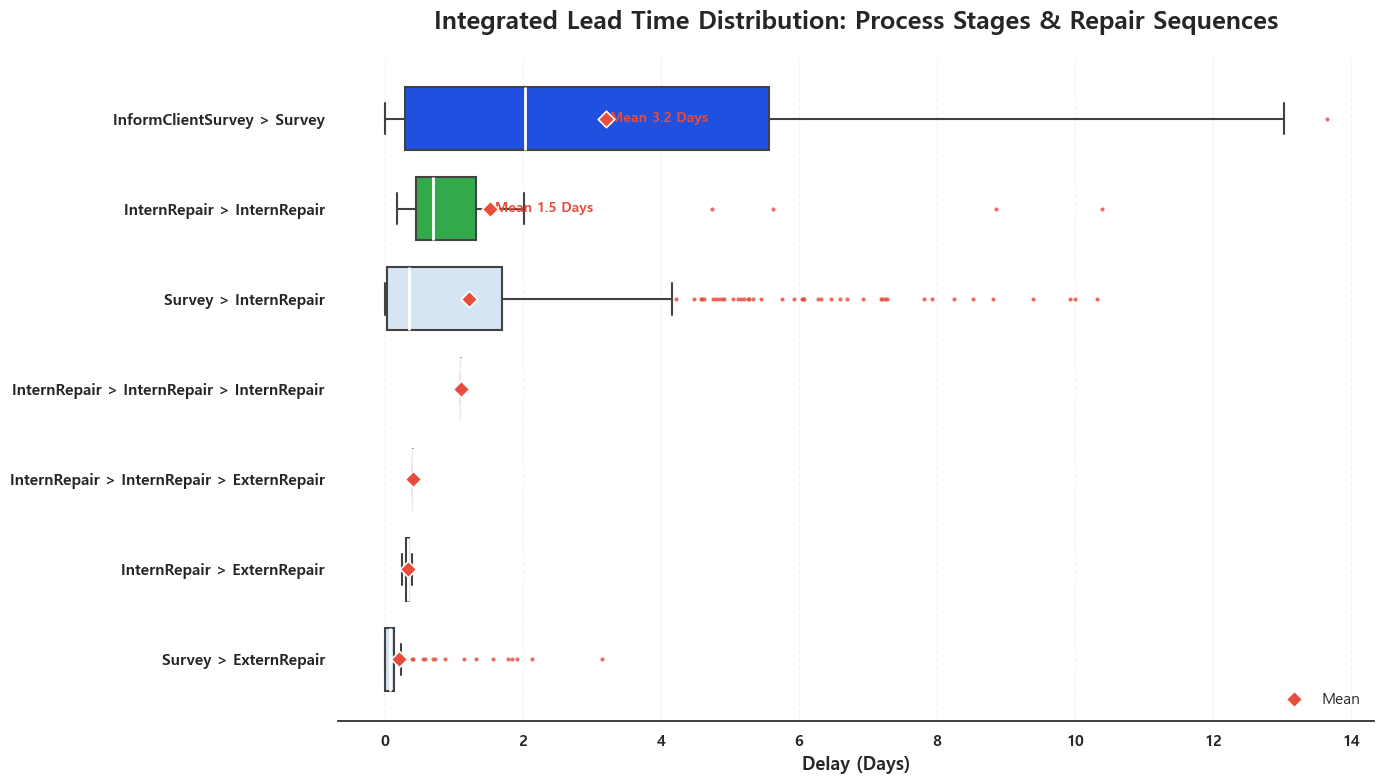

In [84]:
# =====================================================
# Color Palette
# =====================================================
pal = {
    "Stage_Crit": "#0040FF",
    "Stage_Base": "#D1E5F8",
    "Seq_Crit": "#1EBE41",
    "Seq_Base": "#D1F8D5"
}

text_dark = "#222222"

# =====================================================
# Plot Data
# =====================================================
df_box = df_plot.copy()

# 평균 기준 정렬
order = (
    df_box.groupby("target")["diff_days"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# 평균 계산
mean_df = (
    df_box.groupby("target", as_index=False)["diff_days"]
    .mean()
)

mean_df["target"] = pd.Categorical(
    mean_df["target"],
    categories=order,
    ordered=True
)

mean_df = mean_df.sort_values("target")

# =====================================================
# Colors
# =====================================================
colors = []

for target in order:

    category = (
        df_box.loc[df_box["target"] == target, "category"]
        .iloc[0]
    )

    if category == "Stage":
        colors.append(
            pal["Stage_Crit"]
            if target == "InformClientSurvey > Survey"
            else pal["Stage_Base"]
        )

    else:
        colors.append(
            pal["Seq_Crit"]
            if target == "InternRepair > InternRepair"
            else pal["Seq_Base"]
        )

# =====================================================
# Plot
# =====================================================
plt.figure(figsize=(14,8))

ax = sns.boxplot(
    data=df_box,
    x="diff_days",
    y="target",
    order=order,
    palette=colors,
    linewidth=1.5,
    width=0.7,
    fliersize=3,
    flierprops={
        "marker":"o",
        "markerfacecolor":"#E74C3C",
        "markeredgecolor":"none",
        "alpha":0.8
    }
)

# =====================================================
# Median (흰색)
# =====================================================
for line in ax.lines[4::6]:
    line.set_color("white")
    line.set_linewidth(2)

# =====================================================
# Mean (◆)
# =====================================================
ax.scatter(
    mean_df["diff_days"],
    np.arange(len(mean_df)),
    marker="D",
    s=70,
    color="#E74C3C",
    edgecolor="white",
    linewidth=1.2,
    zorder=5,
    label="Mean"
)

# =====================================================
# Critical Mean Annotation
# =====================================================
for _, row in mean_df.iterrows():

    if row["target"] in [
        "InformClientSurvey > Survey",
        "InternRepair > InternRepair"
    ]:

        y = list(order).index(row["target"])

        ax.text(
            row["diff_days"] + 0.06,
            y,
            f"Mean {row['diff_days']:.1f} Days",
            fontsize=10,
            fontweight="bold",
            color="#E74C3C",
            va="center"
        )

# =====================================================
# Style
# =====================================================
plt.title(
    "Integrated Lead Time Distribution: Process Stages & Repair Sequences",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Delay (Days)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("")

plt.xticks(fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")

ax.xaxis.grid(True, linestyle="--", alpha=0.25)

sns.despine(left=True)

plt.legend(
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.show()

In [85]:
repair_compare_df = repair_merged_df[repair_merged_df["InformClientWrongPlace_end"].isna()].copy()
repair_compare_df.shape

(927, 58)

In [86]:
# estimatedrepairtime을 범주형으로 변환
repair_compare_df["EstimatedRepairTime"] = (repair_compare_df["EstimatedRepairTime"].astype(int).astype(str))

In [87]:
order = ["60", "120", "160", "220", "240", "360", "480"]

repair_compare_df["EstimatedRepairTime"] = pd.Categorical(
    repair_compare_df["EstimatedRepairTime"],
    categories=order,
    ordered=True
)

In [88]:
mean_df = (
    repair_compare_df
    .groupby(
        ["EstimatedRepairTime", "repair_group"],
        observed=True,          # 중요
        as_index=False
    )["repair_time_diff"]
    .mean()
    .rename(columns={"repair_time_diff": "mean_diff"})
)

In [89]:
print(repair_compare_df[["EstimatedRepairTime", "repair_group", "repair_time_diff"]].head())

print(repair_compare_df["EstimatedRepairTime"].dtype)
print(repair_compare_df["repair_group"].dtype)
print(repair_compare_df["repair_time_diff"].dtype)

  EstimatedRepairTime    repair_group  repair_time_diff
0                 240    SingleRepair             -24.0
1                 120  MultipleRepair             120.0
2                 220    SingleRepair               0.0
3                 120    SingleRepair               0.0
4                 120    SingleRepair             -12.0
category
object
float64


In [90]:
print(repair_compare_df["EstimatedRepairTime"].unique())

['240', '120', '220', '480', '360', '60', '160']
Categories (7, object): ['60' < '120' < '160' < '220' < '240' < '360' < '480']


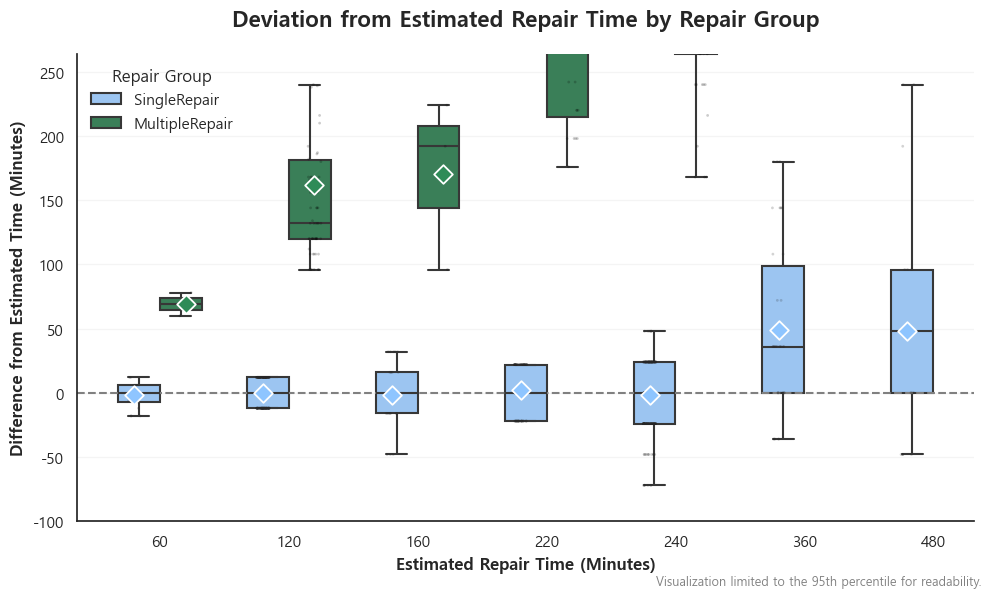

In [91]:
# 동일한 estimared Repair Time을 부여받았을 때, single과 multi는 얼마나 차이가 나는가?
from matplotlib.lines import Line2D

palette = {
    "SingleRepair": "#8EC5FF",
    "MultipleRepair": "#2E8B57"
}

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=repair_compare_df,
    x="EstimatedRepairTime",
    y="repair_time_diff",
    hue="repair_group",
    palette=palette,
    width=0.65,
    linewidth=1.5,
    showfliers=False
)

sns.stripplot(
    data=repair_compare_df,
    x="EstimatedRepairTime",
    y="repair_time_diff",
    hue="repair_group",
#    fill=True,
    dodge=True,
    color="black",
    alpha=0.20,
    size=2
)

# boxplot에서 single/multi 위치와 맞추기 위함.
offset = {
    "SingleRepair": -0.2,
    "MultipleRepair": 0.2
}

for _, row in mean_df.iterrows():

    x = order.index(str(row["EstimatedRepairTime"])) + offset[row["repair_group"]]

    ax.scatter(
        x,
        row["mean_diff"],
        marker="D",
        s=90,
        color=palette[row["repair_group"]],
        edgecolor="white",
        linewidth=1.3,
        zorder=20
    )

#    ax.text(
#        x,
#        row["mean_diff"] + 0.05,
#        f"{row['mean_diff']:.1f}",
#        ha="center",
#        fontsize=9,
#        fontweight="bold"
#    )

    
# 범례 중복 제거
handles, labels = ax.get_legend_handles_labels()

plt.legend(
    handles[:2],
    labels[:2],
    title="Repair Group",
    frameon=False
)

# 기준선
plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.5
)

ylim = repair_compare_df["repair_time_diff"].quantile(0.95)
plt.ylim(-100, ylim)

plt.title(
    "Deviation from Estimated Repair Time by Repair Group",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Estimated Repair Time (Minutes)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Difference from Estimated Time (Minutes)",
    fontsize=12,
    fontweight="bold"
)

plt.figtext(
    0.99,
    0.01,
    "Visualization limited to the 95th percentile for readability.",
    ha="right",
    fontsize=9,
    color="gray"
)

plt.grid(axis="y", alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

In [92]:
repair_compare_df["repair_time_diff_days"] = repair_compare_df["repair_time_diff"] / (60 * 24)

In [93]:
single = repair_compare_df.loc[repair_compare_df["repair_group"] == "SingleRepair", "repair_time_diff_days"]
multi = repair_compare_df.loc[repair_compare_df["repair_group"] == "MultipleRepair", "repair_time_diff_days"]

stat, p = mannwhitneyu(single, multi, alternative = "two-sided")

print(stat)
print(p)

574.5
1.3414456644097218e-73


In [94]:
def cliffs_delta(x, y):
    gt = 0
    lt = 0

    for i in x:
        gt += np.sum(i > y)
        lt += np.sum(i < y)

    delta = (gt - lt) / (len(x) * len(y))

    return delta

In [95]:
delta = cliffs_delta(single.values, multi.values)
print(delta)

-0.9886909448818898


## 2-1. 담당자별 Task 분석

In [97]:
df_complete = event_table[event_table["eventtype"] == "complete"].copy()
complete_cnt = df_complete['originator'].value_counts().reset_index()
complete_cnt.columns = ['originator', 'complete_cnt']

df_start = event_table[event_table["eventtype"] == "start"].copy()
start_cnt = df_start['originator'].value_counts().reset_index()
start_cnt.columns = ['originator', 'start_cnt']

# merge
originator_merged = pd.merge(complete_cnt, start_cnt, on = 'originator', how = 'outer') # (outer : 없는 담당자도 살리기 위함)
originator_merged

,originator,complete_cnt,start_cnt
0,Anne,433.0,433.0
1,Barbara,214.0,214.0
2,Ben,60.0,60.0
3,Cindy,194.0,194.0
4,Dian,1372.0,874.0
5,DoIt,NaN,66.0
6,Edd,186.0,186.0
7,Eric,49.0,49.0
8,FixIt,NaN,66.0
9,Jacky,219.0,219.0


In [98]:
df_complete = event_table[event_table["eventtype"] == "complete"].copy()

# Extern Repair는 start에서 가져오기
extern_start = event_table[(event_log['eventtype'] == 'start') & (event_table['taskID'] == 'ExternRepair')].copy()

# complete에 추가
df_complete_aug = pd.concat([df_complete, extern_start], ignore_index = True) # complete인 담당자 + externrepair 담당자

In [99]:
originator_df = df_complete_aug['originator'].value_counts().reset_index()
originator_df.columns = ['originator', 'count']
originator_df['ratio'] = originator_df['count'] / originator_df['count'].sum()
originator_df

,originator,count,ratio
0,System,4635,0.485289
1,Monica,1555,0.162810
2,Dian,1372,0.143650
3,Anne,433,0.045336
4,Jacky,219,0.022930
5,Barbara,214,0.022406
6,John,198,0.020731
7,Cindy,194,0.020312
8,Paul,194,0.020312
9,Edd,186,0.019474


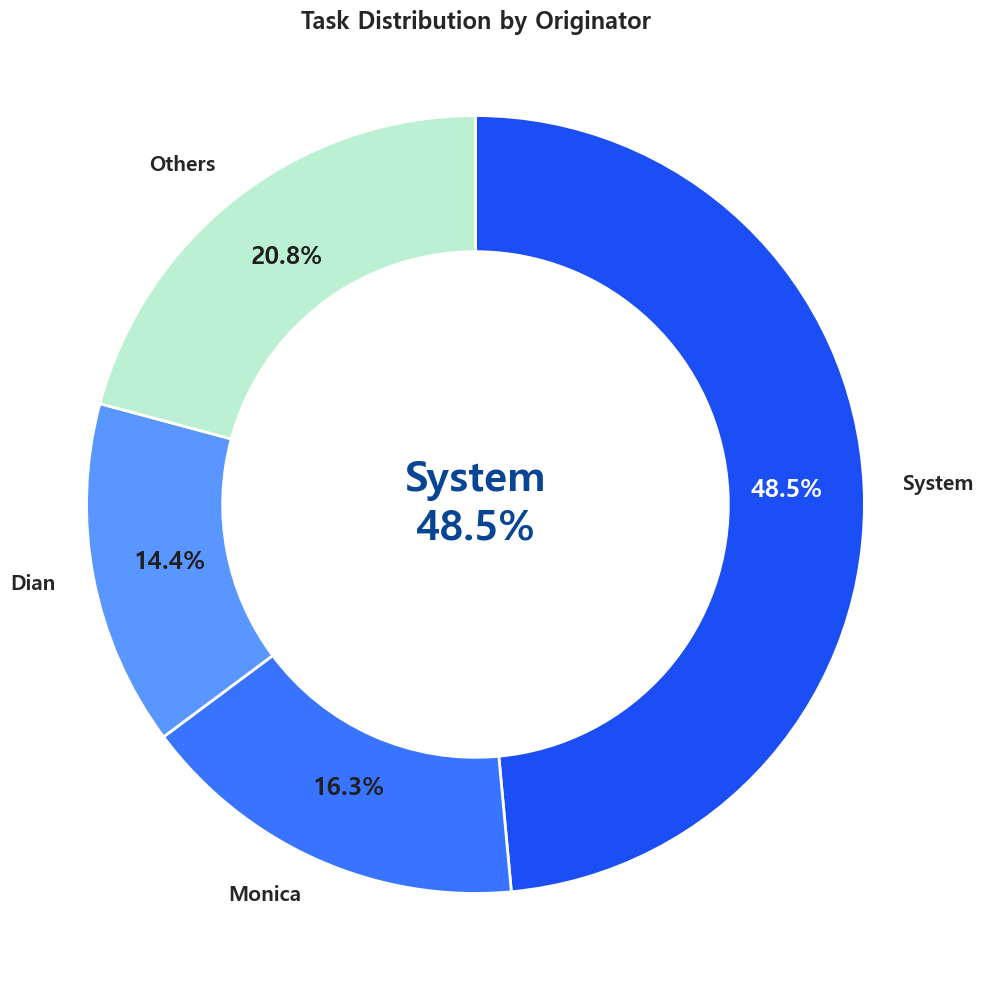

In [100]:
plt.figure(figsize = (10, 10), facecolor = 'white')

top_n = 3

# 1. ratio 내림차순 정렬
df_sorted = originator_df.sort_values("ratio", ascending = False).reset_index(drop = True)

top_df = df_sorted.head(top_n)
others_df = df_sorted.iloc[top_n:]

other_row = pd.DataFrame({"originator" : ["Others"]
                          , "cnt" : [others_df["count"].sum()]
                          , "ratio" : [others_df["ratio"].sum()]
                         })
plot_df = pd.concat([top_df, other_row], ignore_index = True)

color_map = {
    "System": "#1B4EF5",
    "Monica": "#3874FF",
    "Dian": "#5996FF",
    "Others": "#BBF1D2"
}

colors = [color_map[x] for x in plot_df["originator"]]

wedges, texts, autotexts = plt.pie(plot_df["ratio"]
                                   , labels = plot_df["originator"]
                                   , autopct = '%1.1f%%' # autopct=lambda p: f"{p:.1f}%" if p >= 4 else ""
                                   , startangle = 90
                                   , counterclock = False
                                   , colors = colors
                                   , pctdistance = 0.8
                                   , wedgeprops = {'width': 0.35, 'edgecolor': 'w', 'linewidth': 2} #wedgeprops=dict(width=0.78, edgecolor='white', linewidth=1.2)
                                  )

for text in texts:
    text.set_fontweight('bold')
    
plt.setp(texts, fontsize=15)
plt.setp(autotexts, fontsize=18, weight = "bold", color="#1f1f1f")

# System만 흰색으로 변경
for originator, autotext in zip(plot_df["originator"], autotexts):
    if originator == "System":
        autotext.set_color("white")
        autotext.set_fontweight("bold")

plt.text(0, 0, "System\n48.5%", ha = 'center', va = 'center', fontsize = 30, weight = 'bold', color = '#084594')

plt.title("Task Distribution by Originator", fontsize = 17, weight = "bold", pad = 1)
plt.axis('equal')
plt.tight_layout()

plt.savefig("Task Distribution by Originator", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

In [101]:
# 담장자별 task 분포
task_by_originator = event_table.groupby(["originator", "taskID"]).size().reset_index(name = "count")
task_by_originator["ratio"] = task_by_originator.groupby("originator")["count"].transform(lambda x: x / x.sum())

In [102]:
task_order = [
    'FirstContact',
    'MakeTicket',
    'ArrangeSurvey',
    'InformClientWrongPlace',
    'InformClientSurvey',
    'Survey',
    'InternRepair',
    'ImmediateRepair',
    'ExternRepair',
    'RepairReady',
    'SendTicketToFinAdmin',
    'ReadyInformClient',
    'TicketReady'
]

In [103]:
task_pivot = task_by_originator.pivot_table(index = "originator"
                                          , columns = "taskID"
                                          , values = "ratio"
                                          , fill_value = 0
                                         )
task_pivot = task_pivot.reindex(columns = task_order, fill_value = 0) # 프로세스 순서대로 컬럼 재정렬
task_pivot

taskID,FirstContact,MakeTicket,ArrangeSurvey,InformClientWrongPlace,InformClientSurvey,Survey,InternRepair,ImmediateRepair,ExternRepair,RepairReady,SendTicketToFinAdmin,ReadyInformClient,TicketReady
originator,,,,,,,,,,,,,
Anne,0.000000,0.000000,0.000000,0.000000,0.0,0.503464,0.069284,0.427252,0.0,0.0,0.0,0.0,0.0
Barbara,0.000000,0.000000,0.000000,0.000000,0.0,0.518692,0.070093,0.411215,0.0,0.0,0.0,0.0,0.0
Ben,0.000000,0.000000,0.000000,0.000000,0.0,0.583333,0.350000,0.066667,0.0,0.0,0.0,0.0,0.0
Cindy,0.000000,0.000000,0.000000,0.000000,0.0,0.484536,0.515464,0.000000,0.0,0.0,0.0,0.0,0.0
Dian,0.207480,0.389136,0.390472,0.012912,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
DoIt,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0
Edd,0.000000,0.000000,0.000000,0.000000,0.0,0.435484,0.564516,0.000000,0.0,0.0,0.0,0.0,0.0
Eric,0.000000,0.000000,0.000000,0.000000,0.0,0.469388,0.448980,0.081633,0.0,0.0,0.0,0.0,0.0
FixIt,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0


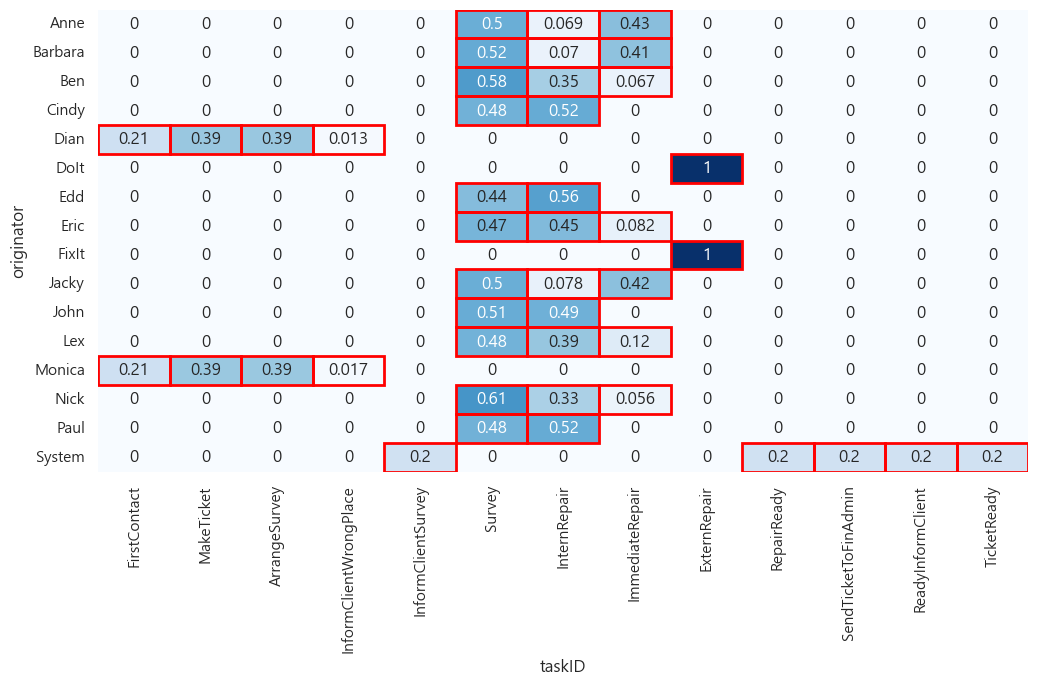

In [104]:
plt.figure(figsize = (12, 6))
sns.heatmap(task_pivot, annot = True, cmap = "Blues", cbar = False)

for i in range(len(task_pivot)):
    for j in range(len(task_pivot.columns)):
        if 0 < task_pivot.iloc[i, j] < 10 : # 0보다 크고 10보다 작은 값
            plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fill = False, edgecolor = "red", lw = 2))

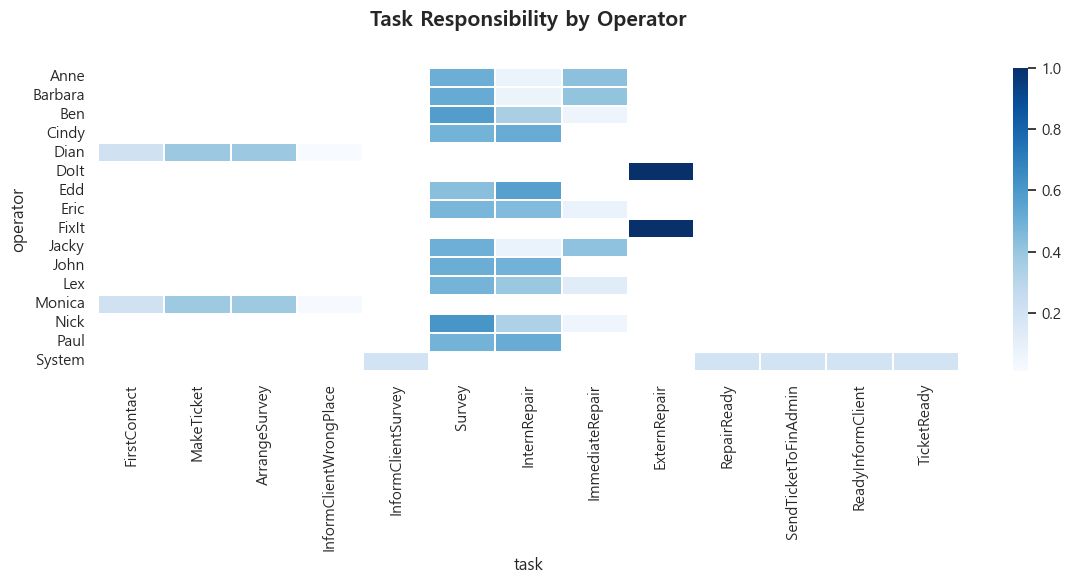

In [105]:
plt.figure(figsize = (12, 6))

mask = task_pivot == 0

sns.heatmap(task_pivot, cmap = "Blues", mask = mask, linewidths = 0.2, linecolor = "white")
plt.title("Task Responsibility by Operator", fontsize = 15, fontweight = "bold", pad = 30)
plt.xlabel("task")
plt.ylabel("operator")

plt.tight_layout()
plt.savefig("Task Responsibility by Operator_heatmap", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

In [106]:
transition_df = pd.read_sql("""
SELECT 
    caseID,
    taskID AS prev_task,
    originator AS prev_actor,
    timestamp AS start_time,

    LEAD(taskID) OVER (PARTITION BY caseID ORDER BY timestamp) AS next_task,
    LEAD(originator) OVER (PARTITION BY caseID ORDER BY timestamp) AS next_actor,
    LEAD(timestamp) OVER (PARTITION BY caseID ORDER BY timestamp) AS next_time,

    TIMESTAMPDIFF(SECOND, timestamp, LEAD(timestamp) OVER (PARTITION BY caseID ORDER BY timestamp)) / 60 AS transition_time_min,
    
    (TIMESTAMPDIFF(SECOND, timestamp, LEAD(timestamp) OVER (PARTITION BY caseID ORDER BY timestamp)) / 60) / 60 AS transition_time_hr,
    (TIMESTAMPDIFF(SECOND, timestamp, LEAD(timestamp) OVER (PARTITION BY caseID ORDER BY timestamp)) / 60) / 1440 AS transition_time_day

FROM repair_event_log_clean
ORDER BY caseID, timestamp
""", conn)

In [107]:
transition_df

,caseID,prev_task,prev_actor,start_time,next_task,next_actor,next_time,transition_time_min,transition_time_hr,transition_time_day
0,1,FirstContact,Dian,1970-01-02 08:08:00,MakeTicket,Dian,1970-01-02 08:08:00,0.0,0.000000,0.000000
1,1,MakeTicket,Dian,1970-01-02 08:08:00,MakeTicket,Dian,1970-01-02 08:11:00,3.0,0.050000,0.002083
2,1,MakeTicket,Dian,1970-01-02 08:11:00,ArrangeSurvey,Dian,1970-01-02 08:11:00,0.0,0.000000,0.000000
3,1,ArrangeSurvey,Dian,1970-01-02 08:11:00,ArrangeSurvey,Dian,1970-01-02 08:16:00,5.0,0.083333,0.003472
4,1,ArrangeSurvey,Dian,1970-01-02 08:16:00,InformClientSurvey,System,1970-01-02 08:16:00,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
13257,1000,InternRepair,John,1970-01-19 18:34:00,RepairReady,System,1970-01-19 18:34:00,0.0,0.000000,0.000000
13258,1000,RepairReady,System,1970-01-19 18:34:00,SendTicketToFinAdmin,System,1970-01-20 01:11:00,397.0,6.616667,0.275694
13259,1000,SendTicketToFinAdmin,System,1970-01-20 01:11:00,ReadyInformClient,System,1970-01-20 02:25:00,74.0,1.233333,0.051389
13260,1000,ReadyInformClient,System,1970-01-20 02:25:00,TicketReady,System,1970-01-20 02:25:00,0.0,0.000000,0.000000


In [108]:
def classify_handover(prev_actor, next_actor):
    if pd.isna(prev_actor) or pd.isna(next_actor):
        return "Unknown"
    elif prev_actor == "System" and next_actor != "System":
        return "System > Human"
    elif prev_actor != "System" and next_actor != "System" and prev_actor != next_actor:
        return "Human > Human"
    elif prev_actor == next_actor:
        return "Same"
    elif prev_actor != "System" and next_actor == "System":
        return "Human > System"
    else:
        return "Other"

In [109]:
transition_df["handover_type"] = transition_df.apply(
    lambda x: classify_handover(x["prev_actor"], x["next_actor"])
    , axis = 1)

In [110]:
transition_df["transition"] = (transition_df["prev_task"].fillna("") + " > " + transition_df["next_task"].fillna(""))

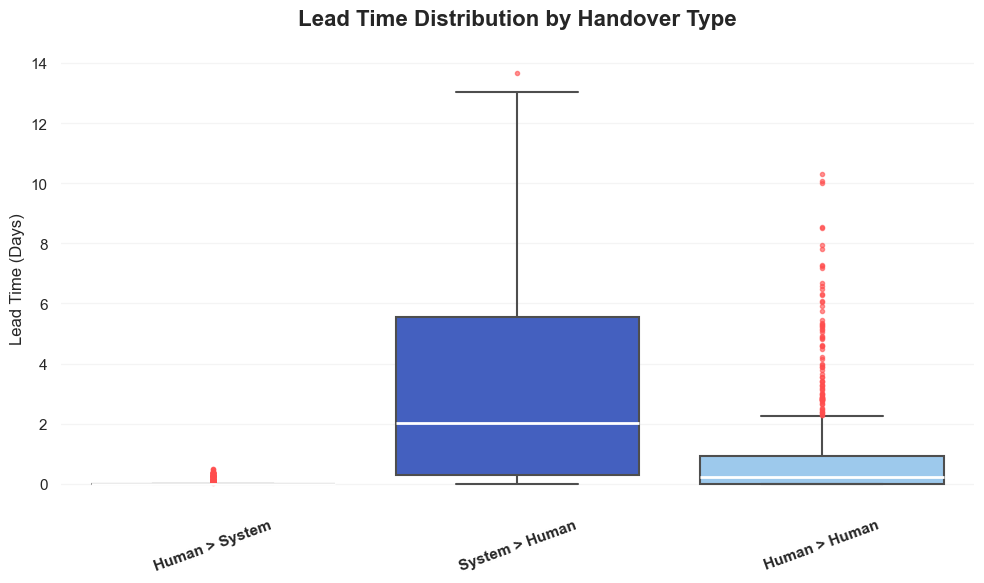

In [111]:
plot_df = transition_df[~transition_df["handover_type"].isin(["Same", "Unknown"])]

palette = {
    "Human > System": "#B0BEC5",
    "System > Human": "#2F55D4",
    "Human > Human": "#90CAF9"
}

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

ax = sns.boxplot(data = plot_df
                 , x = "handover_type"
                 , y = "transition_time_day"
                 , palette = palette
                 , linewidth = 1.5
                 , fliersize = 3
                 , flierprops = {"marker" : "o", "markerfacecolor" : "#FF4D4D", "markeredgecolor" : "#FF4D4D", "alpha" : 0.6}
                )

for line in ax.lines[4::6]:
    line.set_color("white")
    line.set_linewidth(2)

plt.title("Lead Time Distribution by Handover Type", fontsize = 16, fontweight = "bold", pad = 20)
plt.xlabel("")
plt.ylabel("Lead Time (Days)", fontsize = 12)

plt.xticks(rotation = 20, fontsize = 11, fontweight = "bold")
plt.yticks(fontsize = 11)

ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle = '-', alpha = 0.2)

sns.despine(left = True, bottom = True)
plt.tight_layout()

plt.savefig("Lead Time Distribution by Handover Type", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

In [113]:
# Human -> Human 필터링
hh_df = transition_df[transition_df["handover_type"] == "Human > Human"].copy()

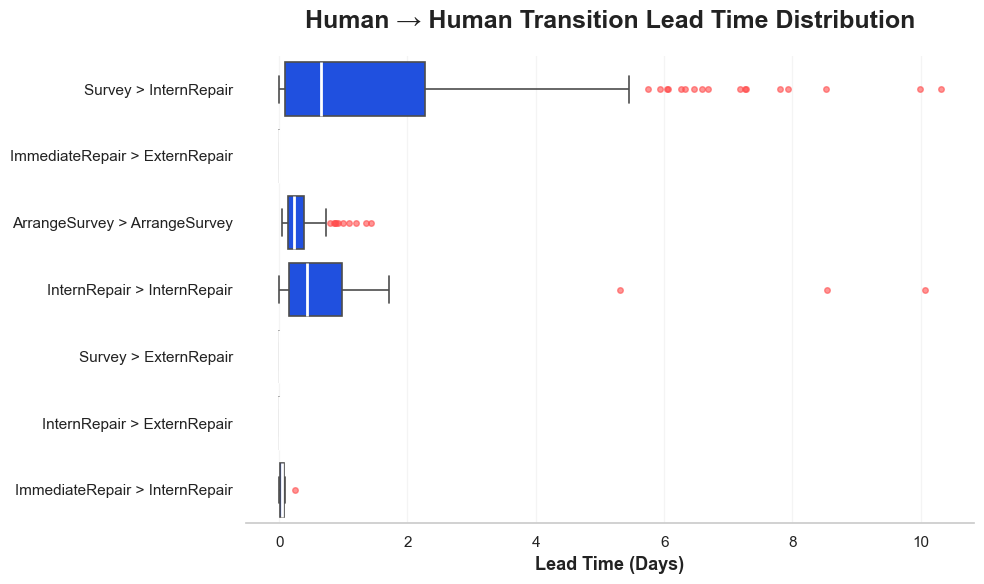

In [114]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

ax = sns.boxplot(data = hh_df
                 , x = "transition_time_day"
                 , y = "transition"
                 , color = "#0040FF"
                 , linewidth = 1.2
                 , fliersize = 4
                 , flierprops = {"marker" : "o", "markerfacecolor" : "#FF4D4D", "markeredgecolor" : "#FF4D4D", "alpha" : 0.6}
                )

for line in ax.lines[4::6]:
    line.set_color("white")
    line.set_linewidth(2)

plt.title("Human → Human Transition Lead Time Distribution", fontsize = 18, fontweight = "bold", pad = 20, color = "#222222")
plt.xlabel("Lead Time (Days)",  fontsize = 13, fontweight = 'bold', color = "#222222")
plt.ylabel("")

plt.xticks(fontsize = 11, color = "#222222")
plt.yticks(fontsize = 11, color = "#222222")

ax.xaxis.grid(True, alpha = 0.2)
ax.yaxis.grid(False)

sns.despine(left = True)
plt.tight_layout()
plt.show()

In [115]:
# Human -> System 필터링
hs_df = transition_df[transition_df["handover_type"] == "Human > System"]

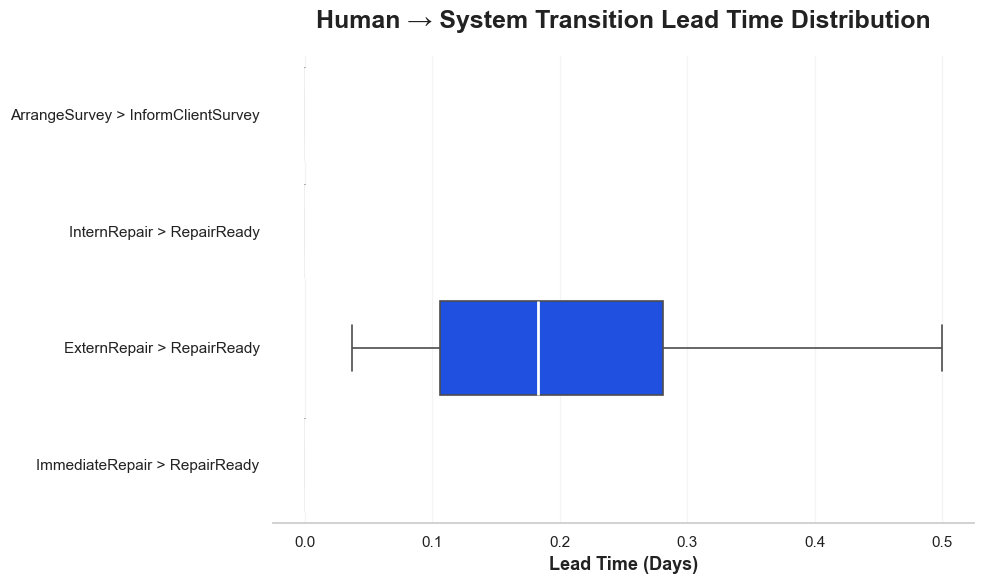

In [116]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

ax = sns.boxplot(data = hs_df
                 , x = "transition_time_day"
                 , y = "transition"
                 , color = "#0040FF"
                 , linewidth = 1.2
                 , fliersize = 4
                 , flierprops = {"marker" : "o", "markerfacecolor" : "#FF4D4D", "markeredgecolor" : "#FF4D4D", "alpha" : 0.6}
                )

for line in ax.lines[4::6]:
    line.set_color("white")
    line.set_linewidth(2)

plt.title("Human → System Transition Lead Time Distribution", fontsize = 18, fontweight = "bold", pad = 20, color = "#222222")
plt.xlabel("Lead Time (Days)",  fontsize = 13, fontweight = 'bold', color = "#222222")
plt.ylabel("")

plt.xticks(fontsize = 11, color = "#222222")
plt.yticks(fontsize = 11, color = "#222222")

ax.xaxis.grid(True, alpha = 0.2)
ax.yaxis.grid(False)

sns.despine(left = True)
plt.tight_layout()
plt.show()

In [117]:
# System > Human
sh_df = transition_df[transition_df["handover_type"] == "System > Human"]

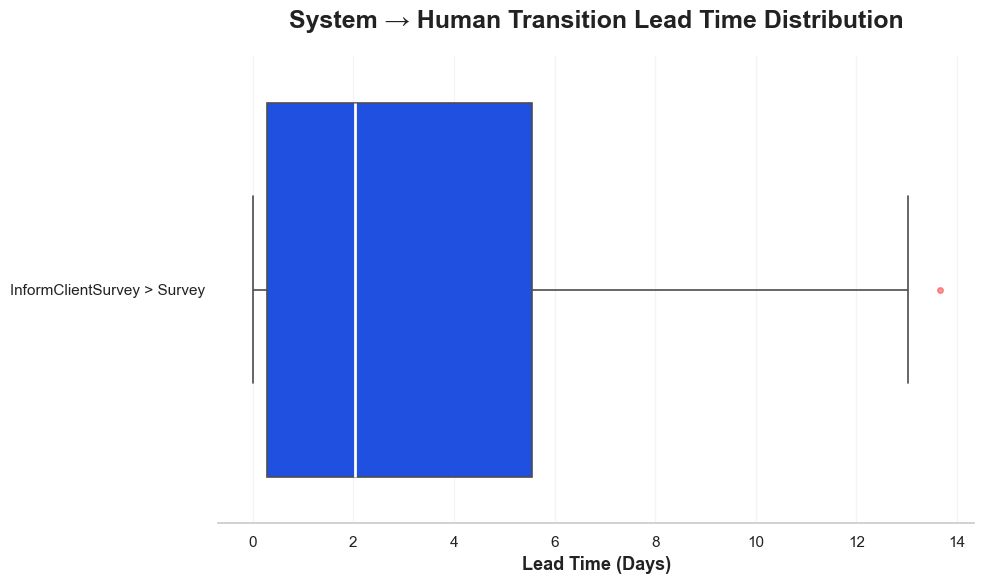

In [118]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

ax = sns.boxplot(data = sh_df
                 , x = "transition_time_day"
                 , y = "transition"
                 , color = "#0040FF"
                 , linewidth = 1.2
                 , fliersize = 4
                 , flierprops = {"marker" : "o", "markerfacecolor" : "#FF4D4D", "markeredgecolor" : "#FF4D4D", "alpha" : 0.6}
                )

for line in ax.lines[4::6]:
    line.set_color("white")
    line.set_linewidth(2)

plt.title("System → Human Transition Lead Time Distribution", fontsize = 18, fontweight = "bold", pad = 20, color = "#222222")
plt.xlabel("Lead Time (Days)",  fontsize = 13, fontweight = 'bold', color = "#222222")
plt.ylabel("")

plt.xticks(fontsize = 11, color = "#222222")
plt.yticks(fontsize = 11, color = "#222222")

ax.xaxis.grid(True, alpha = 0.2)
ax.yaxis.grid(False)

sns.despine(left = True)
plt.tight_layout()
plt.show()

In [119]:
# 내부에서 담당자 변경이 일어나는거는 arrnage 밖에 없으므로 따로 필터링
arr_df = transition_df[transition_df["transition"] == "ArrangeSurvey > ArrangeSurvey"].copy()
arr_df["handover_type"].value_counts()

handover_type
Same             804
Human > Human    123
Name: count, dtype: int64

In [120]:
arr_df['handover_type'] = arr_df['handover_type'].replace({'Human > Human': 'Changed'})

In [121]:
summary = (arr_df.groupby("handover_type")["transition_time_min"]
           .agg(avg_day = "mean", median_day = "median", count = "count")
           .reset_index()
          )
summary["ratio"] = summary["count"] / summary["count"].sum()
summary

,handover_type,avg_day,median_day,count,ratio
0,Changed,468.308943,336.0,123,0.132686
1,Same,67.335821,4.0,804,0.867314


In [122]:
same_avg = summary.loc[summary["handover_type"] == "Same", "avg_day"].values[0]
changed_avg = summary.loc[summary["handover_type"] == "Changed", "avg_day"].values[0]

ratio = changed_avg / same_avg
print(f"Changed는 Same 대비 {ratio:.1f}배 느림")

Changed는 Same 대비 7.0배 느림


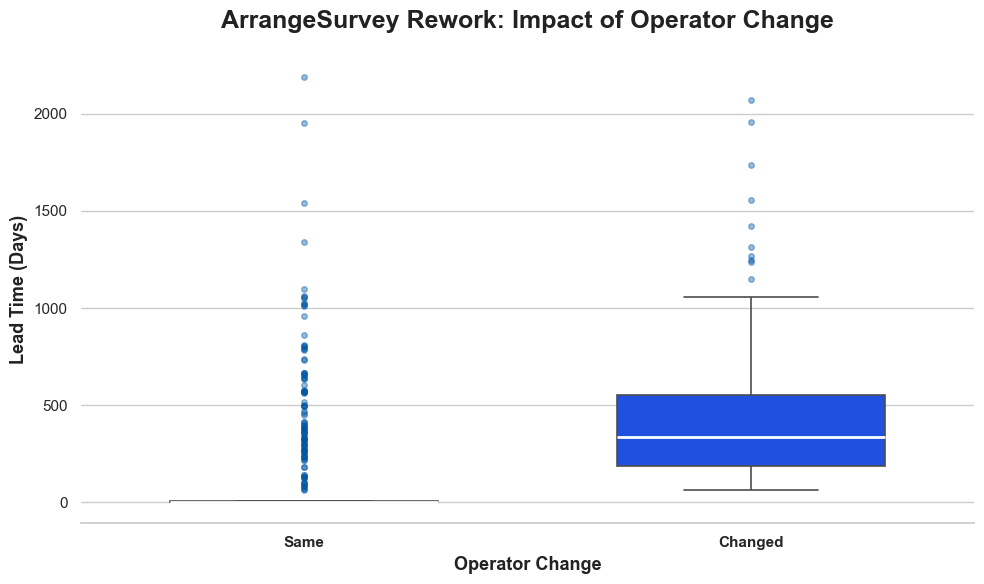

In [123]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

pal = {
    "Same": "#9ecae1",
    "Changed": "#0040FF"
}

ax = sns.boxplot(data = arr_df
                 , x = "handover_type"
                 , y = "transition_time_min"
                 , palette = pal
                 , width = 0.6
                 , linewidth = 1.2
                 , fliersize = 4
                 , flierprops = {"marker" : "o", "markerfacecolor" : "#0056A3", "markeredgecolor" : "#0056A3", "alpha" : 0.4}
                )

for line in ax.lines[4::6]:
    line.set_color("white")
    line.set_linewidth(2)

plt.title("ArrangeSurvey Rework: Impact of Operator Change", fontsize = 18, fontweight = "bold", pad = 20, color = "#222222")
plt.xlabel("Operator Change",  fontsize = 13, fontweight = 'bold', color = "#222222")
plt.ylabel("Lead Time (Days)", fontsize = 13, fontweight = 'bold', color = "#222222")

ax.set_xticklabels(["Same", "Changed"], fontsize = 11, fontweight = "bold")

sns.despine(left = True)
plt.tight_layout()
plt.show()

In [124]:
handover_df = pd.read_sql("""
WITH start_base AS (
	SELECT caseID
		 , taskID
         , timestamp AS start_time
         , originator AS s_org
         , ROW_NUMBER() OVER (PARTITION BY caseID, taskID ORDER BY timestamp) AS seq
	FROM repair_event_log_clean
    WHERE eventtype = "start"
),
complete_base AS (
	SELECT caseID
		 , taskID
         , timestamp AS complete_time
         , originator AS c_org
         , ROW_NUMBER() OVER (PARTITION BY caseID, taskID ORDER BY timestamp) AS seq
	FROM repair_event_log_clean
    WHERE eventtype = "complete"
),
task_duration AS (
	SELECT s.caseID
		 , s.taskID
         , IF(s.s_org = c.c_org, "Same", "Changed") AS hand_over -- 담당자 변경 여부
         , TIMESTAMPDIFF(MINUTE, s.start_time, c.complete_time) AS task_duration_min -- 소요 시간(분 단위)
	FROM start_base s
		INNER JOIN complete_base c ON s.caseID = c.caseID
								   AND s.taskID = c.taskID
                                   AND s.seq = c.seq
	)
SELECT *
FROM task_duration
""", conn)


In [125]:
handover_df

,caseID,taskID,hand_over,task_duration_min
0,1,ArrangeSurvey,Same,5
1,1,InternRepair,Same,216
2,1,MakeTicket,Same,3
3,1,Survey,Same,23
4,2,ArrangeSurvey,Same,4
...,...,...,...,...
3706,999,Survey,Same,21
3707,1000,ArrangeSurvey,Changed,303
3708,1000,InternRepair,Same,240
3709,1000,MakeTicket,Same,4


In [126]:
handover_df["task_duration_day"] = handover_df["task_duration_min"] / (60 * 24)

In [127]:
handover_df["taskID"].unique() # 촛 5개의 task에서 담당자 변경 확인

array(['ArrangeSurvey', 'InternRepair', 'MakeTicket', 'Survey',
       'ImmediateRepair'], dtype=object)

In [128]:
handover_df[handover_df['hand_over'] == 'Changed']["taskID"].unique()

array(['ArrangeSurvey'], dtype=object)

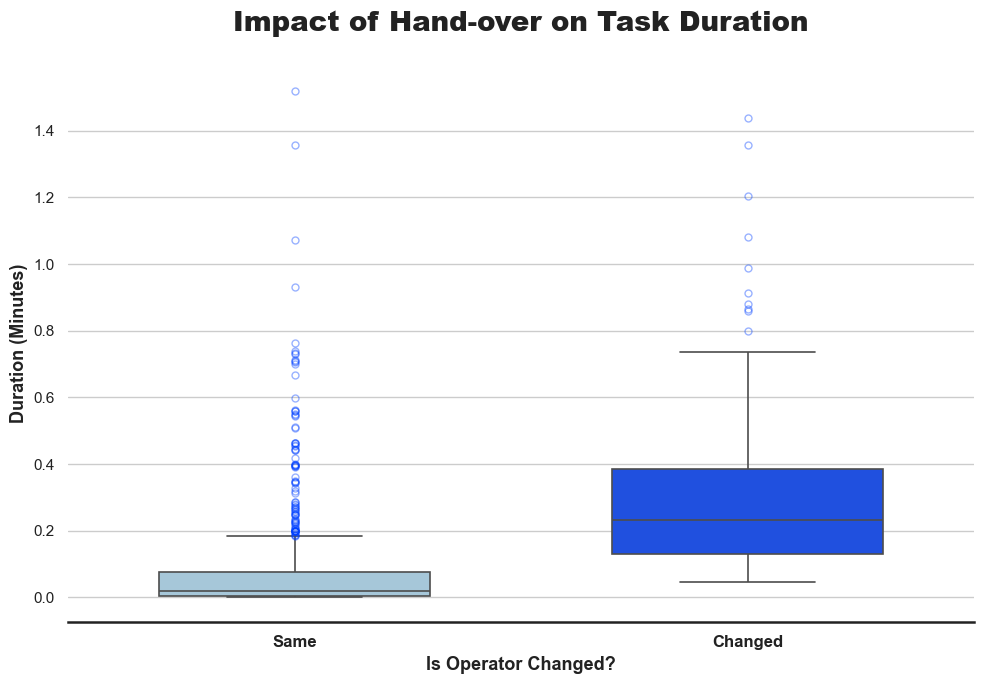

In [129]:
sns.set_style("whitegrid")

pal = {'Same': '#9ecae1', 'Changed': '#0040FF'} # Gray for Same, Deep Blue for Changed

fig, ax = plt.figure(figsize=(10, 7)), plt.gca()

ax = sns.boxplot(x = 'hand_over'
                 , y = 'task_duration_day'
                 , data = handover_df
                 , palette = pal
                 , width = 0.6
                 , showfliers = True # 이상치 표시
                 , linewidth = 1.2
                 , fliersize = 5
                 , flierprops = {"marker": "o", "markeredgecolor": pal['Changed'], "alpha" : 0.4}
                )

plt.title("Impact of Hand-over on Task Duration", fontsize = 20, fontweight = 'black', pad = 25, color = "#222222")
plt.xlabel("Is Operator Changed?", fontsize = 13, fontweight = 'bold', color = "#222222")
plt.ylabel("Duration (Minutes)", fontsize = 13, fontweight = 'bold', color = "#222222")

ax.set_xticklabels(["Same", "Changed"], fontsize = 12, fontweight = "bold", color = "#222222")

sns.despine(left = True, right = True, top = True, bottom = False) # 불필요한 모든 테두리 제거

ax.spines["bottom"].set_color("#222222")
ax.spines["bottom"].set_linewidth(1.8)

ax.xaxis.set_tick_params(width = 1.8, color = "#222222")
ax.tick_params(axis = "x", colors = "#222222")
ax.tick_params(axis = "y", colors = "#222222")

plt.tight_layout()

plt.savefig("Impact of Hand-over on Task Duration", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

In [130]:
# inform client survey 종료 후 survey 시작 전 사이인 3.2일 대기구간 데이터와 해당 케이스 arrange survey 담당자 변경 여부 결합
df_check = pd.read_sql("""
-- 1. 각 케이스별/태스크별 시작과 종료 담당자 매칭 (Hand-over 판별용)
WITH task_originators AS (
	SELECT s.caseID
		 , s.taskID
         , s.originator AS start_org
         , c.originator AS complete_org
         , IF(s.originator = c.originator, 0, 1) AS handover_flag
	FROM (SELECT * FROM repair_event_log_clean WHERE eventtype = 'start') s
    JOIN (SELECT * FROM repair_event_log_clean WHERE eventtype = 'complete') c
		ON s.caseID = c.caseID
        AND s.taskID = c.taskID
),

-- 2. LEAD 함수를 이용해 'Inform Client Survey' 다음의 'Survey' 시작 시간 가져오기
event_flow AS (
	SELECT caseID
		 , taskID
         , timestamp AS current_end_time
         , LEAD(taskID) OVER (PARTITION BY caseID ORDER BY timestamp) AS next_task
         , LEAD(timestamp) OVER (PARTITION BY caseID ORDER BY timestamp) AS next_start_time
	FROM repair_event_log_clean
),

-- 3. 'Inform -> Survey' 구간의 대기 시간(분) 계산
waiting_analysis AS (
	SELECT *
		, TIMESTAMPDIFF(MINUTE, current_end_time, next_start_time) AS wait_min
	FROM event_flow
    WHERE taskID = 'InformClientSurvey'
    AND next_task = 'Survey'
)

-- 4. 최종 병합: 3.2일 대기 구간 데이터와 해당 케이스의 Arrange Survey 담당자 변경 여부 결합
SELECT *
FROM waiting_analysis w
LEFT JOIN task_originators t 
     ON w.caseID = t.caseID
WHERE t.taskID = 'ArrangeSurvey'
""", conn)

In [131]:
df_check

,caseID,taskID,current_end_time,next_task,next_start_time,wait_min,caseID,taskID,start_org,complete_org,handover_flag
0,1,InformClientSurvey,1970-01-02 08:16:00,Survey,1970-01-11 21:33:00,13757,1,ArrangeSurvey,Dian,Dian,0
1,2,InformClientSurvey,1970-01-08 05:25:00,Survey,1970-01-12 04:19:00,5694,2,ArrangeSurvey,Dian,Dian,0
2,3,InformClientSurvey,1970-01-03 01:14:00,Survey,1970-01-06 06:31:00,4637,3,ArrangeSurvey,Dian,Dian,0
3,4,InformClientSurvey,1970-01-03 08:32:00,Survey,1970-01-04 17:03:00,1951,4,ArrangeSurvey,Monica,Monica,0
4,5,InformClientSurvey,1970-01-07 20:52:00,Survey,1970-01-09 22:35:00,2983,5,ArrangeSurvey,Monica,Monica,0
...,...,...,...,...,...,...,...,...,...,...,...
922,996,InformClientSurvey,1970-01-01 18:19:00,Survey,1970-01-02 00:52:00,393,996,ArrangeSurvey,Monica,Monica,0
923,997,InformClientSurvey,1970-01-06 21:04:00,Survey,1970-01-12 10:49:00,8025,997,ArrangeSurvey,Dian,Dian,0
924,998,InformClientSurvey,1970-01-07 01:49:00,Survey,1970-01-15 20:07:00,12618,998,ArrangeSurvey,Dian,Dian,0
925,999,InformClientSurvey,1970-01-07 04:50:00,Survey,1970-01-07 04:50:00,0,999,ArrangeSurvey,Monica,Monica,0


In [132]:
# 담당자 변경 여부별 대기 시간 통계
summary = df_check.groupby('handover_flag')['wait_min'].agg(['count', 'mean', 'median', 'std'])
print(summary)

               count         mean  median          std
handover_flag                                         
0                804  4591.605721  2881.0  4747.649791
1                123  4697.146341  3121.0  4431.954797


In [133]:
# 통계적 유의성 검정
group_same = df_check[df_check['handover_flag'] == 0]['wait_min']
group_changed = df_check[df_check['handover_flag'] == 1]['wait_min']

t_stat, p_val = stats.ttest_ind(group_same, group_changed, equal_var = False)

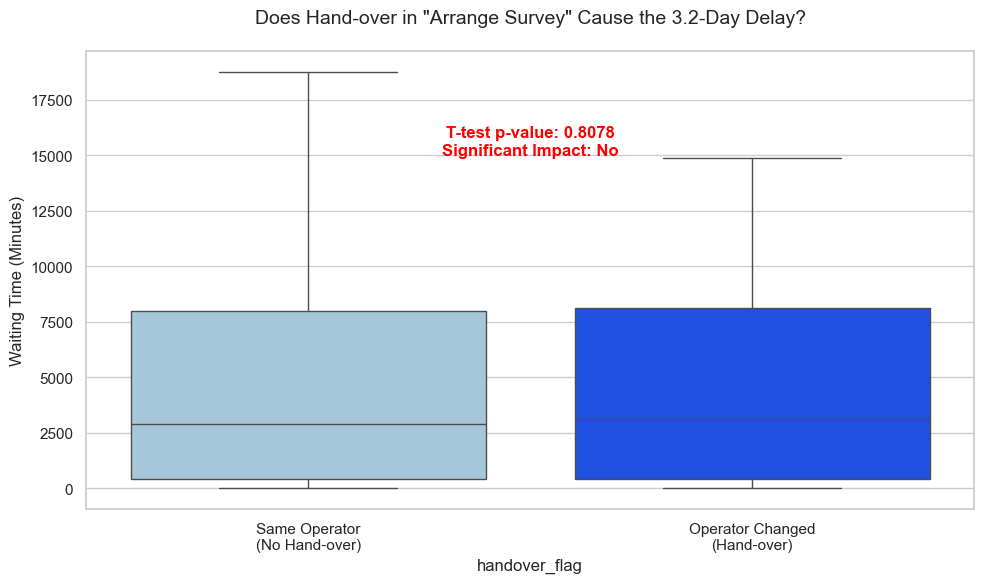

In [134]:
plt.figure(figsize = (10, 6))
sns.set_style("whitegrid")

sns.boxplot(x = "handover_flag", y = "wait_min", data = df_check, palette=['#9ecae1', '#0040FF'], showfliers = False)

plt.title('Does Hand-over in "Arrange Survey" Cause the 3.2-Day Delay?', fontsize=14, pad=20)
plt.xticks([0, 1], ['Same Operator\n(No Hand-over)', 'Operator Changed\n(Hand-over)'])
plt.ylabel('Waiting Time (Minutes)')

plt.text(0.5, 15000
         , f"T-test p-value: {p_val:.4f}\nSignificant Impact: {"Yes" if p_val < 0.05 else "No"}"
         , ha = "center", fontsize = 12, fontweight = "bold", color = "red")
plt.tight_layout()
plt.show()